# Úkol 1a


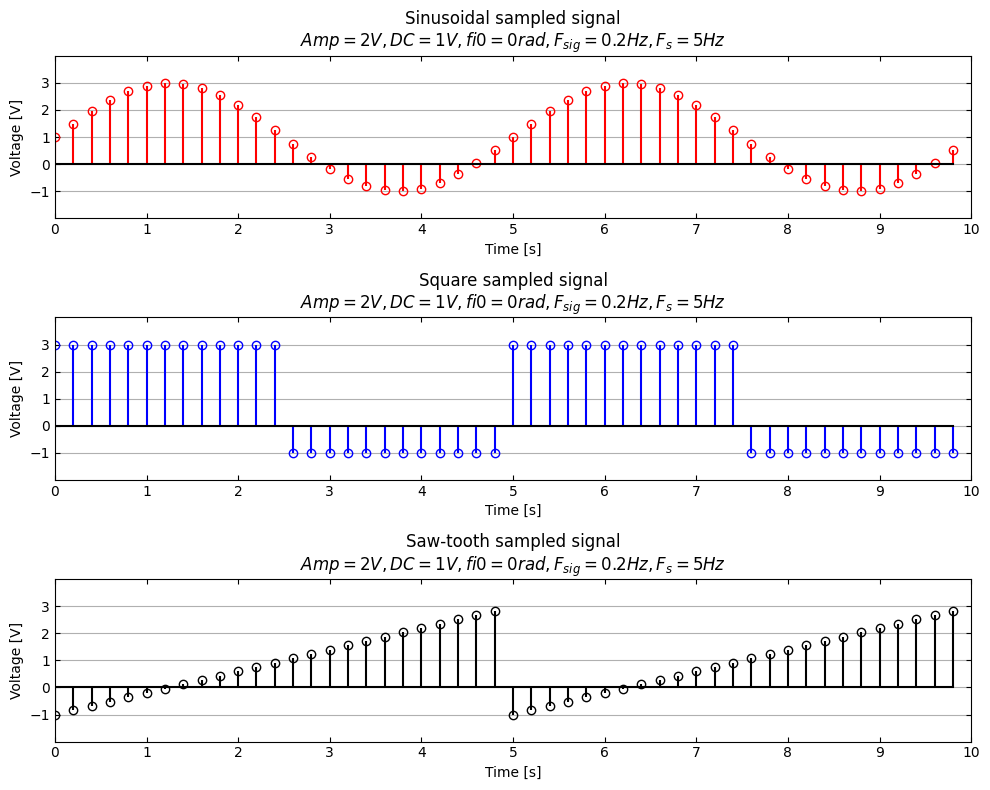

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

U0 = 1.0
A = 2.0
f = 0.2
phi0 = 0.0
Fs = 5.0
T = 10.0

t = np.arange(0, T, 1/Fs)

sine = U0 + A * np.sin(2 * np.pi * f * t + phi0)
square = U0 + A * signal.square(2 * np.pi * f * t + phi0)
saw = U0 + A * signal.sawtooth(2 * np.pi * f * t + phi0)

minY_val = np.floor(min(np.min(sine), np.min(square), np.min(saw)))
maxY_val = np.ceil(max(np.max(sine), np.max(square), np.max(saw)))

yticks = np.arange(minY_val, maxY_val + 1, 1)
xticks = np.arange(0, int(T) + 1, 1)

plt.figure(figsize=(10, 8))

def format_ax(ax, title):
    ax.set_title(title)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage [V]')
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)
    ax.set_xlim(0, T)
    ax.set_ylim(minY_val - 1, maxY_val + 1)
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(axis='y', linestyle='-')

ax1 = plt.subplot(3,1,1)
markerline, stemlines, baseline = ax1.stem(t, sine, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.setp(markerline, markerfacecolor='none', markersize=6, markeredgecolor='red')
plt.setp(stemlines, color='red')
format_ax(ax1, r'Sinusoidal sampled signal' + '\n' + r'$Amp=2V, DC=1V, fi0=0rad, F_{sig}=0.2Hz, F_s=5Hz$')

ax2 = plt.subplot(3,1,2)
markerline, stemlines, baseline = ax2.stem(t, square, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.setp(markerline, markerfacecolor='none', markersize=6, markeredgecolor='blue')
plt.setp(stemlines, color='blue')
format_ax(ax2, r'Square sampled signal' + '\n' + r'$Amp=2V, DC=1V, fi0=0rad, F_{sig}=0.2Hz, F_s=5Hz$')

ax3 = plt.subplot(3,1,3)
markerline, stemlines, baseline = ax3.stem(t, saw, linefmt='k-', markerfmt='ko', basefmt='k-')
plt.setp(markerline, markerfacecolor='none', markersize=6, markeredgecolor='black')
plt.setp(stemlines, color='black')
format_ax(ax3, r'Saw-tooth sampled signal' + '\n' + r'$Amp=2V, DC=1V, fi0=0rad, F_{sig}=0.2Hz, F_s=5Hz$')

plt.tight_layout()
plt.show()


## Komentář

Pro vypracování tohoto úkolu jsem si nejprve importoval nezbytné knihovny pro zobrazení dat v grafech a pro práci s matematickými konstantami.

Následně jsem si definoval všechny parametry signálu do samostatných proměnných a definoval rovnice pro všechny tři signály (sinusový, obdélníkový a pilový).

Poté již stačilo tyto tři signály vykreslit v třech separátních grafech, které obsahují veškeré nezbytné náležitosti a popisy.


# Úkol 1b


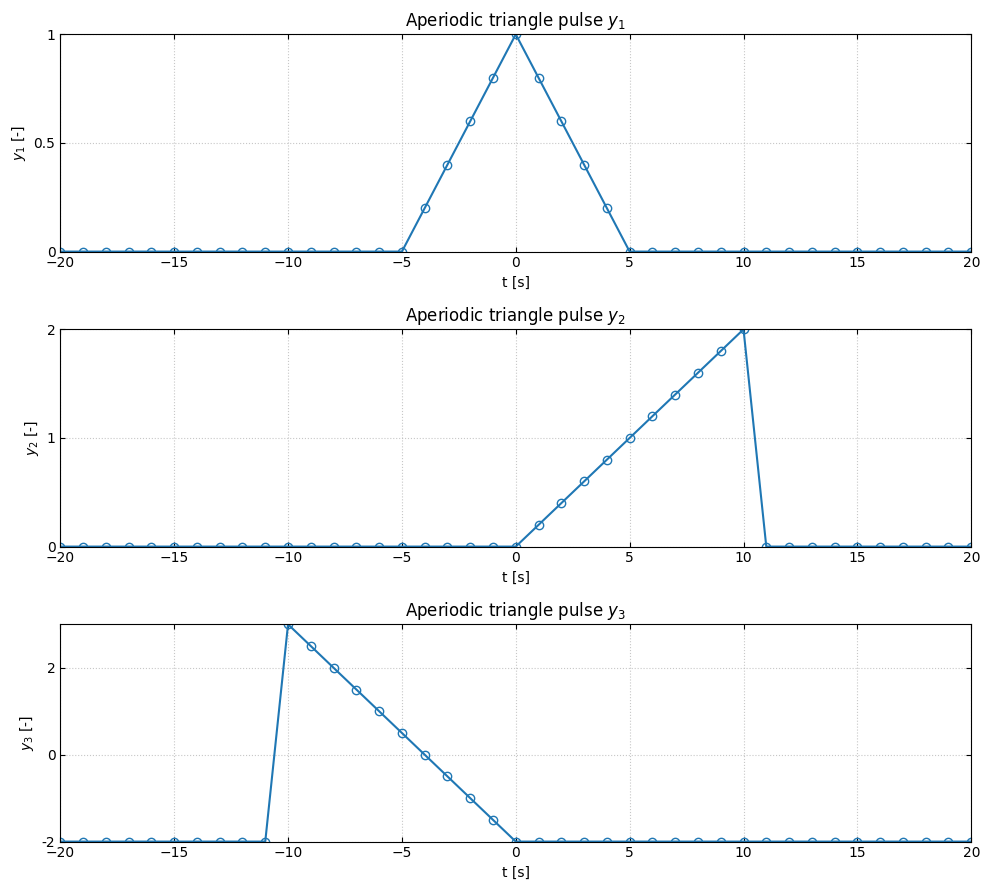

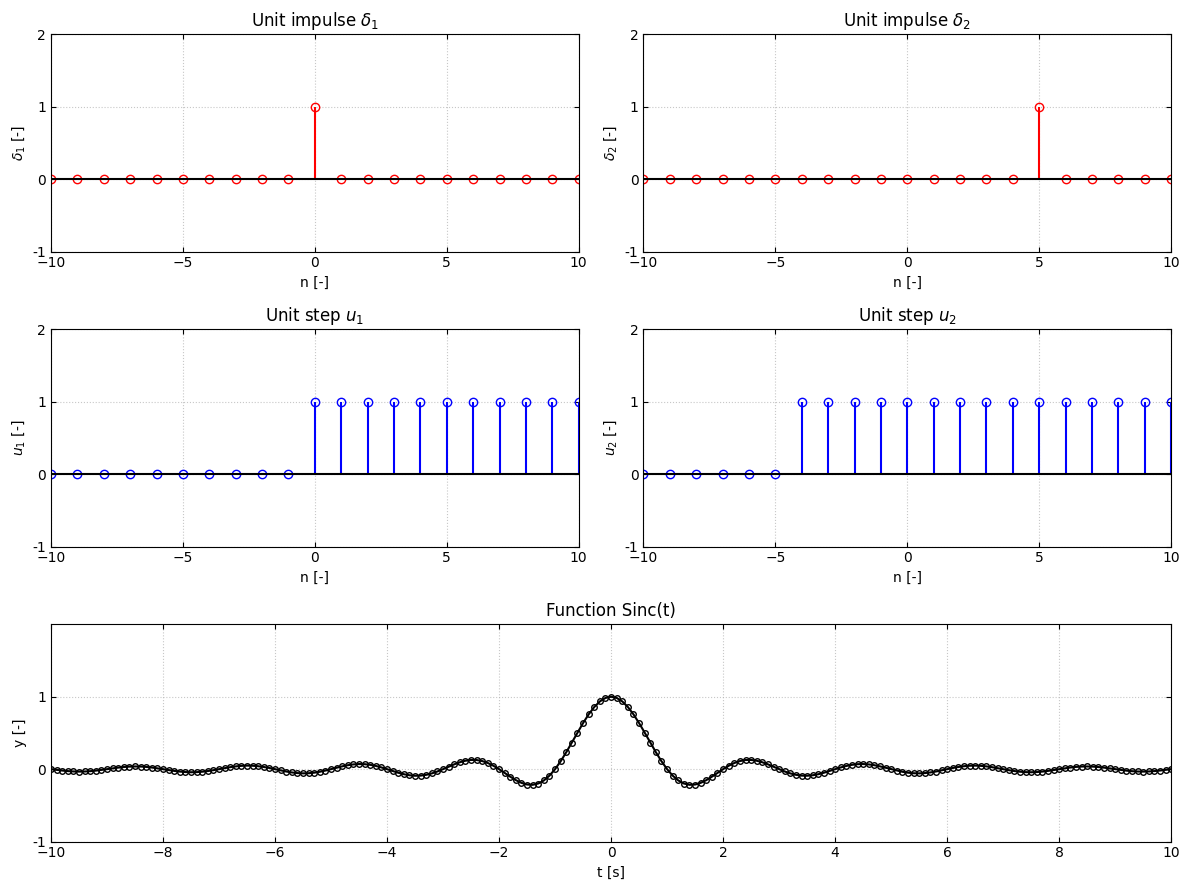

In [7]:
import matplotlib.pyplot as plt
import numpy as np

t_tri_start = -20
t_tri_end   = 20
Ts_tri      = 1

width_tri = 10
skew_y1   = 0
skew_y2   = 1
skew_y3   = -1

n_start = -10
n_end   = 10
Ts_n    = 1

t_sinc_start = -10
t_sinc_end   = 10
Ts_sinc      = 0.1

def tripuls(t, width=1, skew=0):
    t = np.asanyarray(t)
    y = np.zeros_like(t, dtype=float)
    start, end = -width / 2, width / 2
    peak = skew * width / 2
    mask = (t >= start) & (t <= end)

    if skew == 1:
        y[mask] = (t[mask] - start) / (peak - start)
    elif skew == -1:
        y[mask] = (end - t[mask]) / (end - peak)
    else:
        left = (t >= start) & (t <= peak)
        right = (t > peak) & (t <= end)
        if peak > start:
            y[left] = (t[left] - start) / (peak - start)
        else:
            y[left] = 1.0
        if end > peak:
            y[right] = (end - t[right]) / (end - peak)
        else:
            y[right] = 1.0
    return y

def setup_ax(ax, xlim, ylim, yticks, xticks=None):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.set_yticklabels([f'{int(y)}' if y == int(y) else f'{y}' for y in yticks])
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.tick_params(direction='in', top=True, right=True)

t_tri = np.arange(t_tri_start, t_tri_end + Ts_tri, Ts_tri)
y1 = tripuls(t_tri, width_tri, skew_y1)
y2 = 2 * tripuls(t_tri - 5, width_tri, skew_y2)
y3 = 5 * tripuls(t_tri + 5, width_tri, skew_y3) - 2

n = np.arange(n_start, n_end + Ts_n, Ts_n)
delta1 = np.where(n == 0, 1, 0)
delta2 = np.where(n == 5, 1, 0)
u1 = np.where(n >= 0, 1, 0)
u2 = np.where(n >= -4, 1, 0)

t_sinc = np.arange(t_sinc_start, t_sinc_end + Ts_sinc, Ts_sinc)
y_sinc = np.sinc(t_sinc)

plt.figure(figsize=(10, 9))
tri_configs = [
    (y1, r'$y_1$', (0, 1), [0, 0.5, 1]),
    (y2, r'$y_2$', (0, 2), [0, 1, 2]),
    (y3, r'$y_3$', (-2, 3), [-2, 0, 2])
]
for i, (data, label, ylim, yticks) in enumerate(tri_configs):
    ax = plt.subplot(3, 1, i+1)
    ax.plot(t_tri, data, 'o-', markerfacecolor='none', markersize=6)
    ax.set_title(f'Aperiodic triangle pulse {label}')
    ax.set_xlabel('t [s]')
    ax.set_ylabel(f'{label} [-]')
    setup_ax(ax, (t_tri_start, t_tri_end), ylim, yticks)

plt.tight_layout()

plt.figure(figsize=(12, 9))
stem_configs = [
    (321, n, delta1, r'Unit impulse $\delta_1$', r'$\delta_1$', 'r'),
    (322, n, delta2, r'Unit impulse $\delta_2$', r'$\delta_2$', 'r'),
    (323, n, u1, r'Unit step $u_1$', r'$u_1$', 'b'),
    (324, n, u2, r'Unit step $u_2$', r'$u_2$', 'b')
]
for pos, x, y, title, ylabel, col in stem_configs:
    ax = plt.subplot(pos)
    marker, stem, base = ax.stem(x, y, linefmt=f'{col}-', markerfmt=f'{col}o', basefmt='k-')
    plt.setp(marker, markerfacecolor='none')
    ax.set_title(title)
    ax.set_xlabel('n [-]')
    ax.set_ylabel(f'{ylabel} [-]')
    setup_ax(ax, (n_start, n_end), (-1, 2), [-1, 0, 1, 2], xticks=[-10, -5, 0, 5, 10])

ax_sinc = plt.subplot(3, 1, 3)
ax_sinc.plot(t_sinc, y_sinc, 'ko-', markerfacecolor='none', markersize=4)
ax_sinc.set_title('Function Sinc(t)')
ax_sinc.set_xlabel('t [s]')
ax_sinc.set_ylabel('y [-]')
setup_ax(ax_sinc, (t_sinc_start, t_sinc_end), (-1, 2), [-1, 0, 1], xticks=np.arange(-10, 11, 2))

plt.tight_layout()
plt.show()


## Komentář

Stejně jako v minulém úkolu jsem si nejprve importoval nezbytné knihovny pro zobrazení grafů a práci s matematickými konstantami.

Následně jsem si definoval proměnné, které definují intervaly a kroky vzorkování pro jednotlivé signály.

Funkce tripuls slouží ke generování tří aperiodických trojúhelníkových signálů y<sub>1</sub>, y<sub>2</sub>, y<sub>3</sub> na intervalu t = <-20, 20> s rozdílními sklonovými parametry.

Dále jsem vygeneroval a zobrazil jednotkové impulsy δ<sub>1</sub>(n), δ<sub>2</sub>(n) a jednotkové skoky u<sub>1</sub>(n), u<sub>2</sub>(n) na intervalu n = <-10; 10>.

Na závěr jsem vygeneroval a zobrazil průběh funkce y(t) = sinc(t) na intervalu t = <-10; 10>.
